In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# import warnings
# warning.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/Robert/OneDrive/Data/Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Univariate Analysis

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

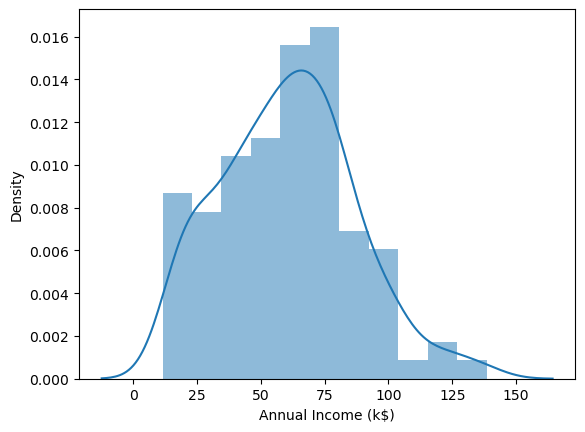

In [5]:
sns.histplot(data=df, x='Annual Income (k$)', stat='density', kde=True, binrange=[0,150], kde_kws={'cut': 3},  edgecolor='none')

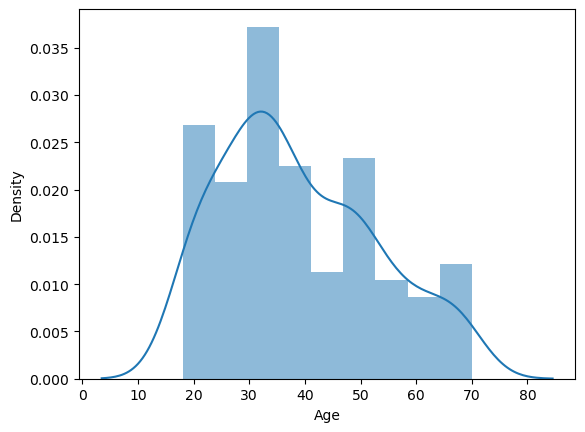

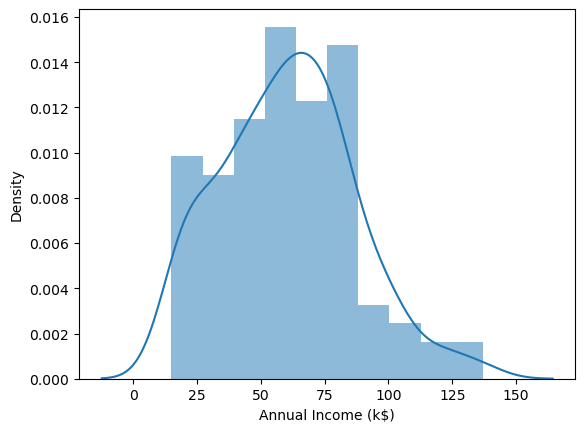

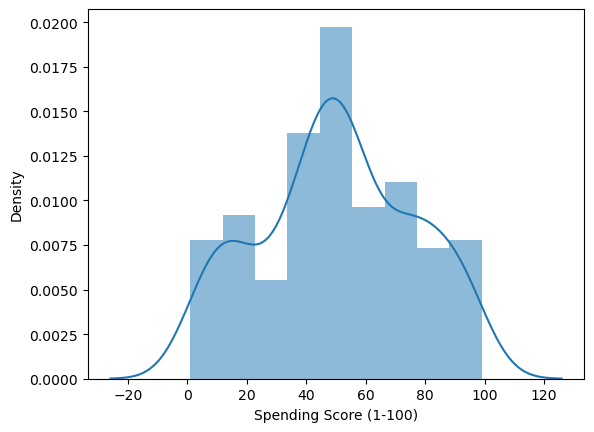

In [6]:
columns = df.columns[2:]
columns_with_genders = df.columns[1:]
for i in columns:
    plt.figure()
    sns.histplot(data = df, x=i, stat='density', kde=True, kde_kws={'cut': 3},  edgecolor='none')

<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

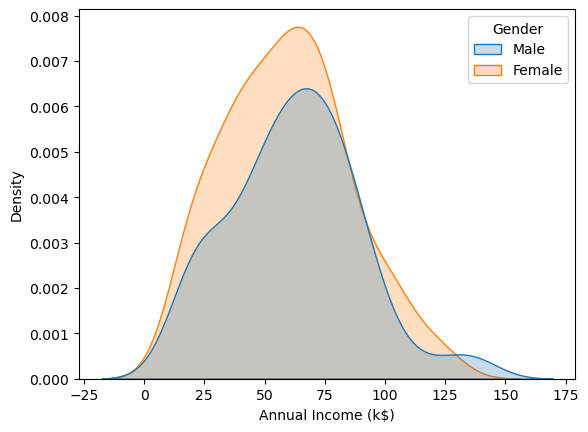

In [7]:
sns.kdeplot(data = df, x='Annual Income (k$)', fill=True, hue='Gender')

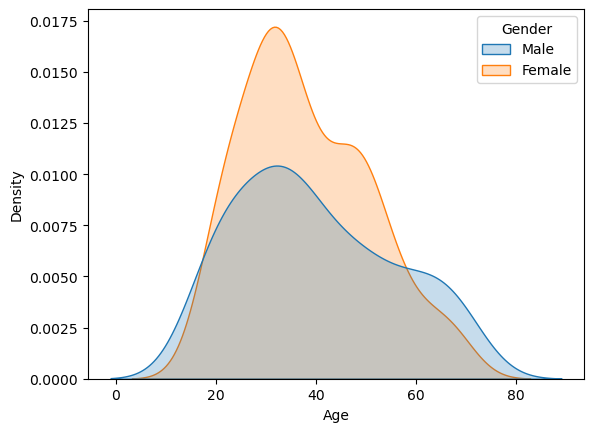

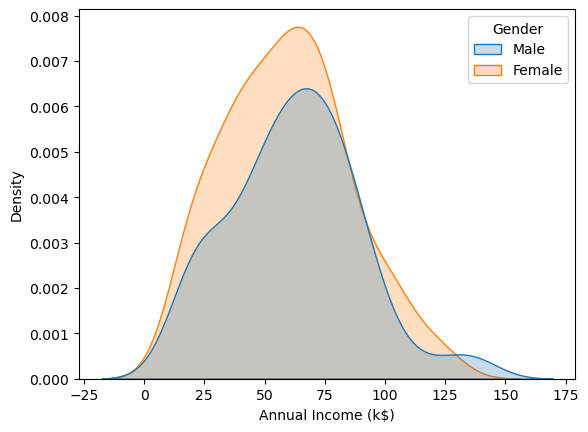

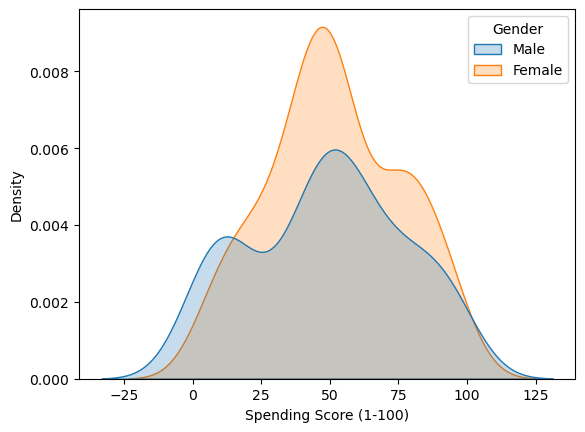

In [8]:
for i in columns:
    plt.figure()
    sns.kdeplot(data=df, x=i, fill=True, hue='Gender')

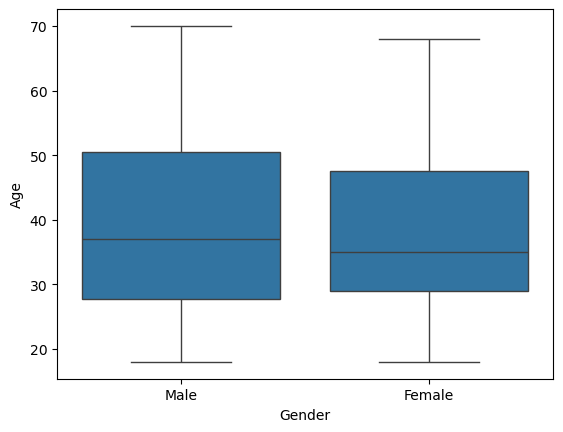

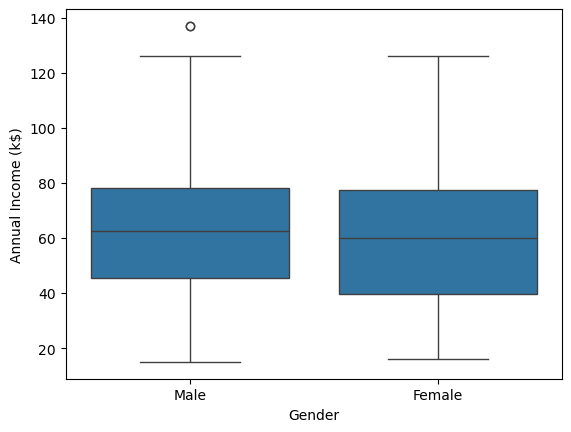

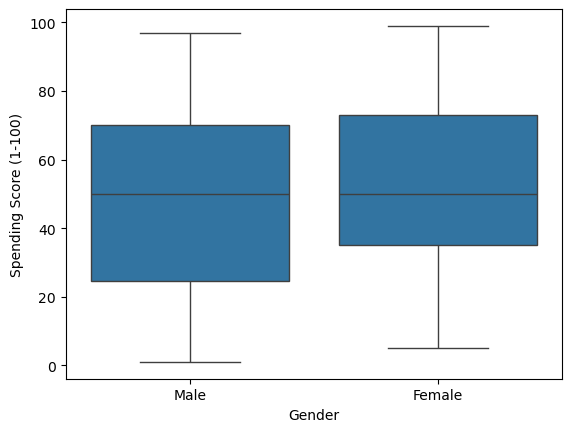

In [9]:
for i in columns:
    plt.figure()
    sns.boxplot(data=df, x='Gender', y=i)

In [10]:
df['Gender'].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

# Bivariate Analysis

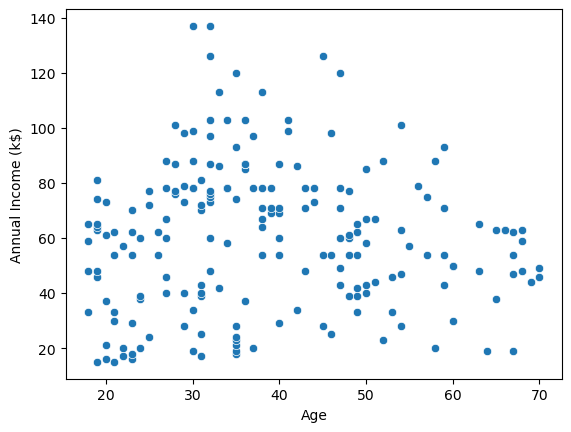

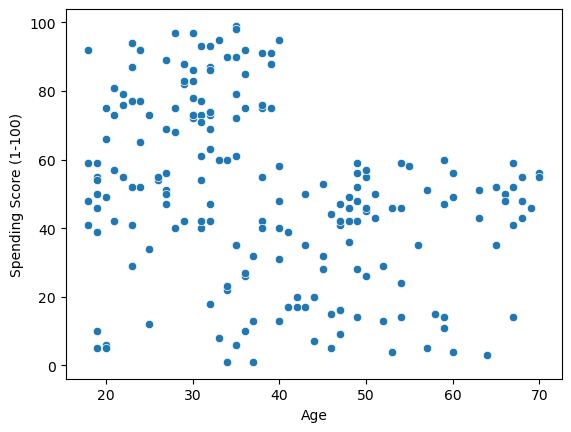

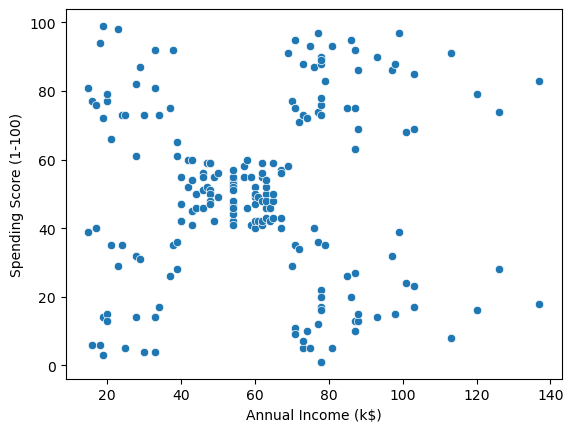

In [11]:
for i, col1 in enumerate(columns):
    for j, col2 in enumerate(columns[i+1:]):
        plt.figure()
        sns.scatterplot(data=df, x=col1, y=col2)

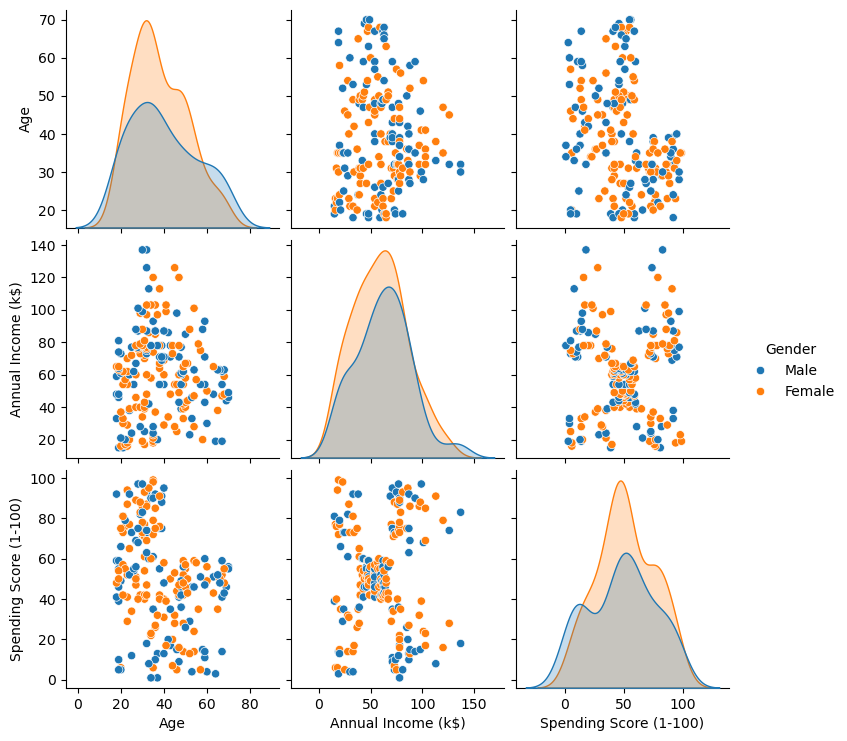

In [12]:
#df=df.drop('CustomerID', axis=1)
sns.pairplot(data=df[columns_with_genders], hue='Gender')

In [13]:
df.groupby(['Gender']).mean()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,,
Female,97.562500,38.098214,59.250000,51.526786
Male,104.238636,39.806818,62.227273,48.511364


In [14]:
df[columns].corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


<Axes: >

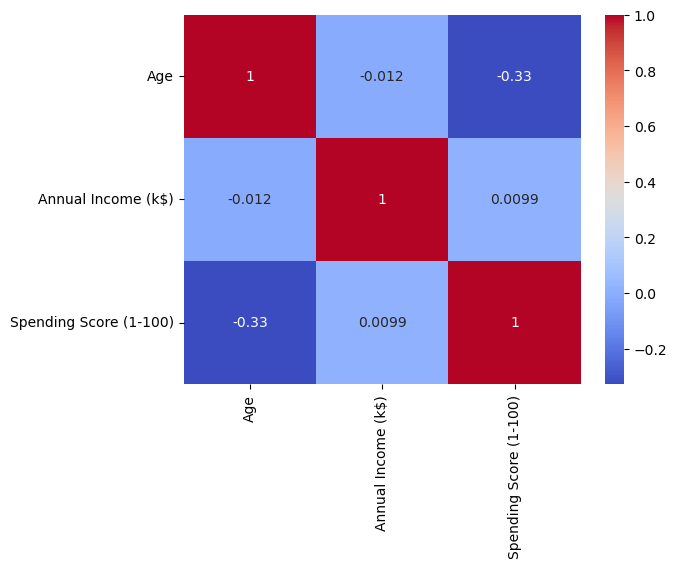

In [15]:
sns.heatmap(df[columns].corr(), annot=True, cmap='coolwarm')

# Clustering - Univariate, Bivariate, Multivariate

In [16]:
clustering1 = KMeans(n_clusters=3)

In [17]:
clustering1.fit(df[['Annual Income (k$)']])

KMeans(n_clusters=3)

In [18]:
clustering1.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int32)

In [19]:
df['Income Cluster'] = clustering1.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [20]:
df['Income Cluster'].value_counts()

Income Cluster
2    92
1    86
0    22
Name: count, dtype: int64

In [21]:
clustering1.inertia_

25341.285871863212

In [22]:
inertia_scores=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[['Annual Income (k$)']])
    inertia_scores.append(kmeans.inertia_)

In [23]:
inertia_scores

[137277.2800000002,
 48660.88888888887,
 23528.152173913048,
 13844.22209821871,
 8667.679614837503,
 7397.476621417797,
 4145.61147186147,
 2871.629365079367,
 2716.5033189033174,
 1939.8966089466087]

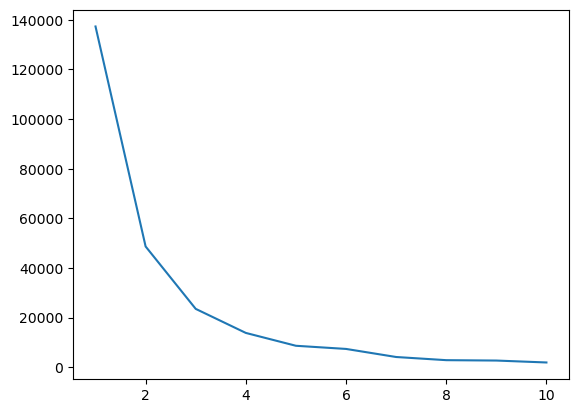

In [24]:
plt.plot(range(1,11), inertia_scores)

In [26]:
df.groupby('Income Cluster')[columns].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,37.545455,108.181818,52.000000
1,40.023256,36.348837,50.081395
2,38.065217,71.804348,49.880435


# Bivariate Clustering

In [86]:
clustering2 = KMeans(n_clusters=5)
clustering2.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
df['Spending and Income Cluster'] = clustering2.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,1,Male,19,15,39,1,1
1,2,Male,21,15,81,1,4
2,3,Female,20,16,6,1,1
3,4,Female,23,16,77,1,4
4,5,Female,31,17,40,1,1


In [28]:
inertia_scores=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
    inertia_scores.append(kmeans.inertia_)

In [29]:
inertia_scores

[269981.28000000014,
 186362.95600651755,
 106348.37306211119,
 73880.64496247198,
 44448.45544793369,
 37558.92202302528,
 37969.942890442886,
 30645.67796189317,
 23226.98198370256,
 20064.59240151932]

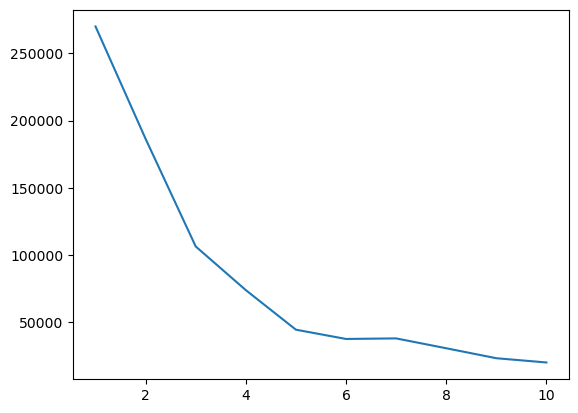

In [30]:
plt.plot(range(1,11), inertia_scores)

In [43]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['x','y']

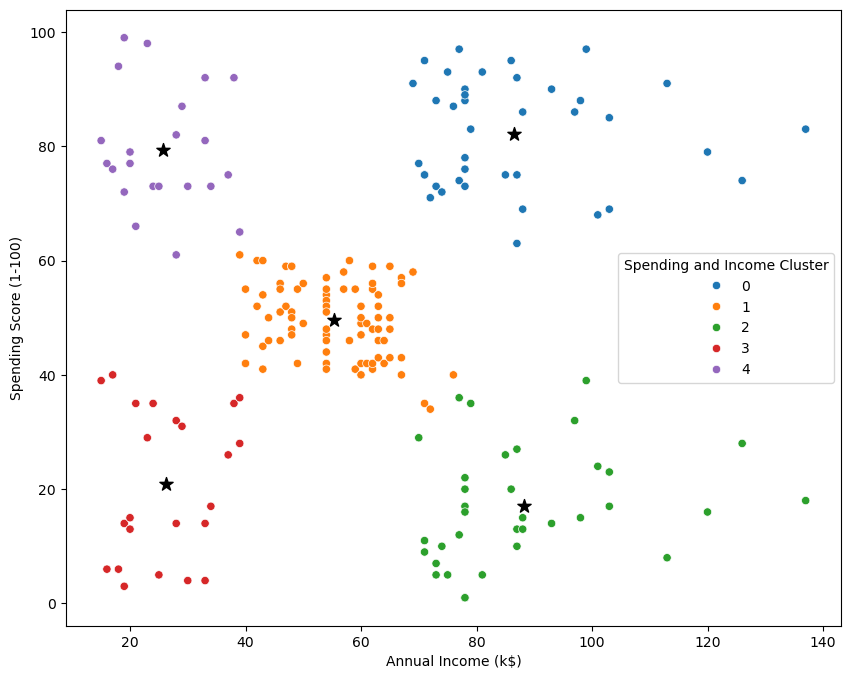

In [77]:
plt.figure(figsize=(10,8))
plt.scatter(data=centers, x='x',y='y', s=100, c='black', marker='*', label='')
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Spending and Income Cluster', palette='tab10')
plt.savefig('clustering_bivariate.png')

In [53]:
pd.crosstab(df['Spending and Income Cluster'], df['Gender'],normalize='index')

Gender,Female,Male
Spending and Income Cluster,,
0,0.538462,0.461538
1,0.592593,0.407407
2,0.457143,0.542857
3,0.608696,0.391304
4,0.590909,0.409091


In [56]:
df.groupby('Spending and Income Cluster')[columns].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending and Income Cluster,,,
0,32.692308,86.538462,82.128205
1,42.716049,55.296296,49.518519
2,41.114286,88.200000,17.114286
3,45.217391,26.304348,20.913043
4,25.272727,25.727273,79.363636


# Multivaraite Clustering

In [89]:
from sklearn.preprocessing import StandardScaler

In [90]:
scaler = StandardScaler()

In [91]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,1,Male,19,15,39,1,1
1,2,Male,21,15,81,1,4
2,3,Female,20,16,6,1,1
3,4,Female,23,16,77,1,4
4,5,Female,31,17,40,1,1


In [92]:
dff = pd.get_dummies(df, drop_first=True)
dff.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster,Gender_Male
0,1,19,15,39,1,1,True
1,2,21,15,81,1,4,True
2,3,20,16,6,1,1,False
3,4,23,16,77,1,4,False
4,5,31,17,40,1,1,False


In [93]:
dff = dff[['Age', 'Annual Income (k$)','Spending Score (1-100)','Gender_Male']]
dff.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


In [94]:
dff = pd.DataFrame(scaler.fit_transform(dff))
dff.head()

,0,1,2,3
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


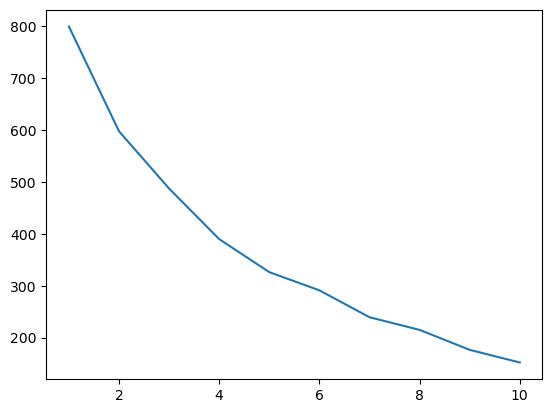

In [95]:
inertia_scores=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(dff)
    inertia_scores.append(kmeans.inertia_)
plt.plot(range(1,11), inertia_scores)

In [96]:
clustering3 = KMeans(n_clusters=4)
clustering3.fit(dff)
dff['Age, Spending, and Income Cluster'] = clustering3.labels_
dff.head()

,0,1,2,3,"Age, Spending, and Income Cluster"
0,-1.424569,-1.738999,-0.434801,1.128152,1
1,-1.281035,-1.738999,1.195704,1.128152,1
2,-1.352802,-1.700830,-1.715913,-0.886405,0
3,-1.137502,-1.700830,1.040418,-0.886405,2
4,-0.563369,-1.662660,-0.395980,-0.886405,0


In [74]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,1,Male,19,15,39,1,3
1,2,Male,21,15,81,1,4
2,3,Female,20,16,6,1,3
3,4,Female,23,16,77,1,4
4,5,Female,31,17,40,1,3
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,0,0
196,197,Female,45,126,28,0,2
197,198,Male,32,126,74,0,0
198,199,Male,32,137,18,0,2


In [75]:
df.to_csv('Clustering.csv')